In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df_list = []
for pqt_file in os.listdir('data/'):
    if pqt_file.endswith('.parquet'):
        df = pd.read_parquet(os.path.join('data/', pqt_file))
        print(f'{pqt_file}: {len(df)} rows')
        df_list.append(df)

base_ind_2004.parquet: 187930 rows
base_ind_2005.parquet: 188755 rows
base_ind_2006.parquet: 222968 rows
base_ind_2007.parquet: 188433 rows
base_ind_2008.parquet: 247819 rows
base_ind_2009.parquet: 240967 rows
base_ind_2010.parquet: 237055 rows
base_ind_2011.parquet: 231657 rows
base_ind_2012.parquet: 223622 rows
base_ind_2013.parquet: 222230 rows
base_ind_2014.parquet: 241181 rows
base_ind_2015.parquet: 120173 rows
base_ind_2016.parquet: 177515 rows
base_ind_2017.parquet: 235332 rows
base_ind_2018.parquet: 230083 rows
base_ind_2019.parquet: 234375 rows
base_ind_2020.parquet: 174227 rows
base_ind_2021.parquet: 192600 rows
base_ind_2022.parquet: 198097 rows
base_ind_2023.parquet: 193382 rows
base_ind_2024.parquet: 187625 rows
base_ind_2025.parquet: 136457 rows


In [39]:
base_full = pd.concat(df_list)

df_select = base_full[
    [
        "ANO4",
        "TRIMESTRE",
        "REGION",
        "AGLOMERADO",
        "PONDERA",
        "PONDII",
        "PONDIIO",
        "CH04",
        "CH06",
        "NIVEL_ED",
        "ESTADO",
        "CAT_OCUP",
        "CAT_INAC",
        "EMPLEO",
        "CH08",
        "PP07H",
        "P21",
        "P47T",
        "caes_division_label",
        "JERARQUIA",
    ]
]

df_select.info()


<class 'pandas.DataFrame'>
Index: 4512483 entries, 0 to 136456
Data columns (total 20 columns):
 #   Column               Dtype  
---  ------               -----  
 0   ANO4                 float64
 1   TRIMESTRE            float64
 2   REGION               float64
 3   AGLOMERADO           float64
 4   PONDERA              float64
 5   PONDII               float64
 6   PONDIIO              float64
 7   CH04                 float64
 8   CH06                 float64
 9   NIVEL_ED             float64
 10  ESTADO               float64
 11  CAT_OCUP             float64
 12  CAT_INAC             float64
 13  EMPLEO               float64
 14  CH08                 float64
 15  PP07H                float64
 16  P21                  float64
 17  P47T                 float64
 18  caes_division_label  str    
 19  JERARQUIA            str    
dtypes: float64(18), str(2)
memory usage: 843.6 MB


In [40]:
map_sexo = {
    1: "Varon",
    2: "Mujer"
}

df_select.CH04 = df_select.CH04.map(map_sexo)

map_region = {
    1: "Gran Buenos Aires",
    40: "NOA",
    41: "NEA",
    42: "Cuyo",
    43: "Pampeana",
    44: "Patagonia"
}

df_select.REGION = df_select.REGION.map(map_region)

map_nivel_ed = {
    1: "Primario Incompleto",
    2: "Primario Completo",
    3: "Secundario Incompleto",
    4: "Secundario Completo",
    5: "Superior o Universitario Incompleto",
    6: "Superior o Universitario Completo",
    7: "Sin Instruccion",
    9: "NS/NC"
}

df_select.NIVEL_ED = df_select.NIVEL_ED.map(map_nivel_ed)

map_estado = {
    0: "Sin respuesta",
    1: "Ocupado",
    2: "Desocupado",
    3: "Inactivo",
    4: "Menor de 10 años"
}

df_select.ESTADO = df_select.ESTADO.map(map_estado)

map_cat_ocup = {
    0: "Inactivo",
    1: "Patron",
    2: "Cuenta Propia",
    3: "Obrero o empleado",
    4: "Trabajador familiar sin remuneracion",
    9: "NS/NR"
}

df_select.CAT_OCUP = df_select.CAT_OCUP.map(map_cat_ocup)

map_cat_inac = {
    0: "Ocupado",
    1: "Jubilado",
    2: "Rentista",
    3: "Estudiante",
    4: "Ama de Casa",
    5: "Menor de 6 años",
    6: "Discapacitado",
    7: "Otros"
}

df_select.CAT_INAC = df_select.CAT_INAC.map(map_cat_inac)

map_empleo = {
    1: "Formal",
    2: "Informal",
    9: "NS/NR"
}

df_select.EMPLEO = df_select.EMPLEO.map(map_empleo)

map_ch08 = {
    1: "Obra Social, PAMI",
    2: "Mutual, Prepagas, Servicio de Emergencia",
    3: "Planes y Seguros Publicos",
    4: "No paga ni le descuentan",
    9: "NS/NR",
    12: "Obra Social y Mutual, Prepegas, Servicio de Emergencia",
    13: "Obra Social y Planes y Seguros Publicos",
    23: "Mutual, Prepagas, Servicio de Emergencia y Planes y Seguros Publicos",
    123: "Obra Social, PAMI, Mutual, Prepagas, Servicio de Emergencia y Planes y Seguros Publicos"
}

df_select.CH08 = df_select.CH08.map(map_ch08)

map_pp07h = {
    0: np.nan,
    1: "Si",
    2: "No"
}

df_select.PP07H = df_select.PP07H.map(map_pp07h)

df_select["situacion_ocupacional"] = np.where(df_select.CAT_INAC == "Ocupado", df_select.CAT_OCUP, df_select.CAT_INAC)

In [41]:
df_select.sort_values(["ANO4", "TRIMESTRE"], ascending=[True, True]).head(10)

,ANO4,TRIMESTRE,REGION,AGLOMERADO,PONDERA,PONDII,PONDIIO,CH04,CH06,NIVEL_ED,...,CAT_OCUP,CAT_INAC,EMPLEO,CH08,PP07H,P21,P47T,caes_division_label,JERARQUIA,situacion_ocupacional
0,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Varon,32.0,Superior o Universitario Incompleto,...,Obrero o empleado,Ocupado,NaN,"Obra Social y Mutual, Prepegas, Servicio de Em...",Si,1440.0,3040.0,SERVICIO DE TRANSPORTE TERRESTRE,Trabajadores asalariados,Obrero o empleado
1,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Mujer,30.0,Secundario Completo,...,Inactivo,Ama de Casa,NaN,"Obra Social y Mutual, Prepegas, Servicio de Em...",NaN,0.0,0.0,NaN,NaN,Ama de Casa
2,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Mujer,2.0,Sin Instruccion,...,Inactivo,Menor de 6 años,NaN,"Obra Social y Mutual, Prepegas, Servicio de Em...",NaN,0.0,0.0,NaN,NaN,Menor de 6 años
3,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Mujer,29.0,Secundario Incompleto,...,Obrero o empleado,Ocupado,NaN,"Obra Social y Mutual, Prepegas, Servicio de Em...",Si,1250.0,1915.0,SERVICIOS SOCIALES Y DE SALUD,Trabajadores asalariados,Obrero o empleado
4,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Varon,4.0,Sin Instruccion,...,Inactivo,Menor de 6 años,NaN,"Obra Social y Mutual, Prepegas, Servicio de Em...",NaN,0.0,0.0,NaN,NaN,Menor de 6 años
5,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Varon,3.0,Sin Instruccion,...,Inactivo,Menor de 6 años,NaN,"Obra Social y Mutual, Prepegas, Servicio de Em...",NaN,0.0,0.0,NaN,NaN,Menor de 6 años
6,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Mujer,24.0,Superior o Universitario Incompleto,...,Obrero o empleado,Ocupado,NaN,"Obra Social, PAMI",Si,450.0,790.0,"COMERCIO AL POR MAYOR, EN COMISION Y AL POR ME...",Trabajadores asalariados,Obrero o empleado
7,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Varon,6.0,Primario Incompleto,...,Inactivo,Estudiante,NaN,"Obra Social y Mutual, Prepegas, Servicio de Em...",NaN,0.0,0.0,NaN,NaN,Estudiante
8,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Varon,4.0,Sin Instruccion,...,Inactivo,Menor de 6 años,NaN,"Obra Social y Mutual, Prepegas, Servicio de Em...",NaN,0.0,0.0,NaN,NaN,Menor de 6 años
9,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Varon,51.0,Secundario Incompleto,...,Cuenta Propia,Ocupado,NaN,No paga ni le descuentan,NaN,1500.0,1500.0,SERVICIO DE TRANSPORTE TERRESTRE,Cuenta propia,Cuenta Propia


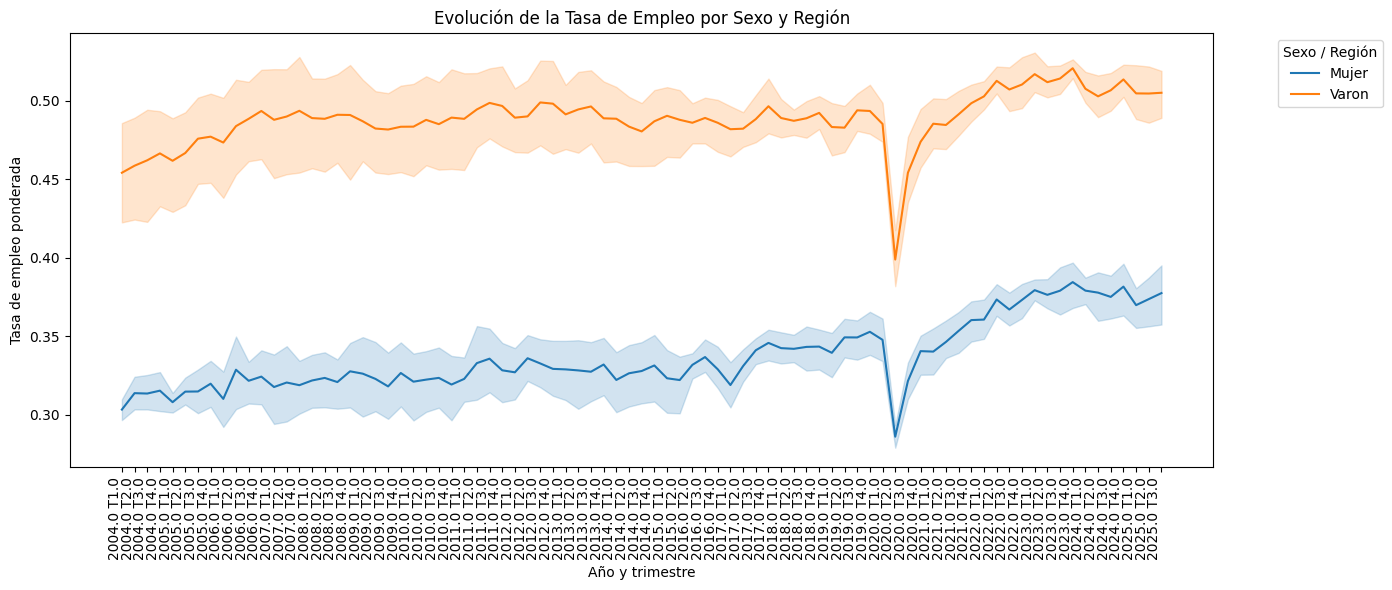

In [58]:
# Graficar la evolución de la tasa de empleo (ESTADO) a lo largo del tiempo, segmentada por sexo (CH04) y región (REGION).
# Se usa ANO4 + TRIMESTRE para ordenar el tiempo y PONDERA como peso muestral.

df_empleo = df_select.copy()
df_empleo["periodo"] = df_empleo["ANO4"].astype(str) + " T" + df_empleo["TRIMESTRE"].astype(str)
df_empleo["ocupado"] = (df_empleo["ESTADO"] == "Ocupado").astype(float)
df_empleo["ocupado_ponderado"] = df_empleo["ocupado"] * df_empleo["PONDERA"]

df_empleo_agg = (
    df_empleo
    .groupby(["ANO4", "TRIMESTRE", "periodo", "CH04", "REGION"], as_index=False)
    .agg({"ocupado_ponderado": "sum", "PONDERA": "sum"})
    .rename(columns={"ocupado_ponderado": "ocupado_total", "PONDERA": "pondera_total"})
    .assign(tasa_empleo=lambda tabla: tabla["ocupado_total"] / tabla["pondera_total"])
)

df_empleo_agg = df_empleo_agg.sort_values(["ANO4", "TRIMESTRE", "CH04", "REGION"])

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=df_empleo_agg,
    x="periodo",
    y="tasa_empleo",
    hue="CH04",
    markers=True,
    dashes=False,
    ax=ax
)
ax.set_title("Evolución de la Tasa de Empleo por Sexo y Región")
ax.set_ylabel("Tasa de empleo ponderada")
ax.set_xlabel("Año y trimestre")
plt.xticks(rotation=90, ha="right")
plt.legend(title="Sexo / Región", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

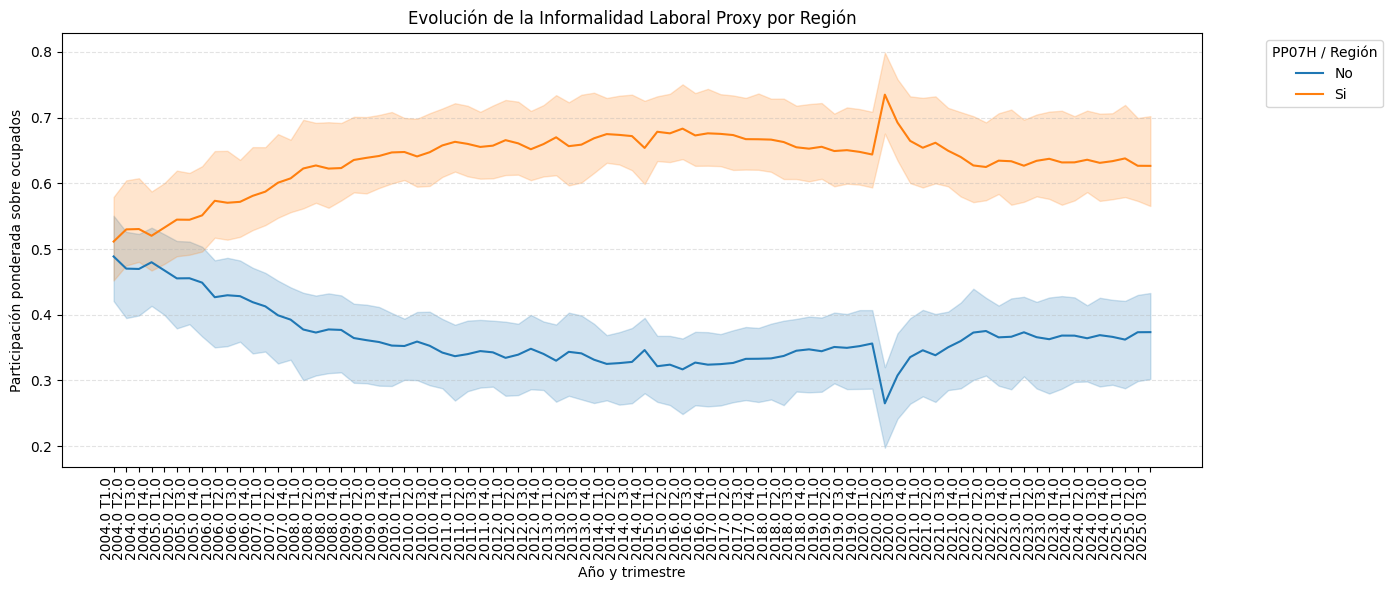

In [57]:
# Graficar la evolución de la informalidad laboral proxy (PP07H) a lo largo del tiempo, segmentada por región.
# Se usa ANO4 + TRIMESTRE para ordenar el tiempo y PONDERA como peso muestral.

df_empleo = df_select.copy()
df_empleo["periodo"] = df_empleo["ANO4"].astype(str) + " T" + df_empleo["TRIMESTRE"].astype(str)

df_empleo = df_empleo[df_empleo["ESTADO"] == "Ocupado"].copy()
df_empleo = df_empleo[df_empleo["PP07H"].isin(["Si", "No"])].copy()

df_empleo_agg = (
    df_empleo
    .groupby(["ANO4", "TRIMESTRE", "periodo", "PP07H", "REGION"], as_index=False)
    .agg(peso_categoria=("PONDERA", "sum"))
)

df_total_agg = (
    df_empleo
    .groupby(["ANO4", "TRIMESTRE", "periodo", "REGION"], as_index=False)
    .agg(peso_total=("PONDERA", "sum"))
)

df_empleo_agg = df_empleo_agg.merge(df_total_agg, on=["ANO4", "TRIMESTRE", "periodo", "REGION"], how="left")
df_empleo_agg["tasa_informalidad"] = df_empleo_agg["peso_categoria"] / df_empleo_agg["peso_total"]
df_empleo_agg = df_empleo_agg.sort_values(["ANO4", "TRIMESTRE", "PP07H", "REGION"])

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=df_empleo_agg,
    x="periodo",
    y="tasa_informalidad",
    hue="PP07H",
    # style="REGION",
    markers=True,
    dashes=False,
    ax=ax
)
ax.set_title("Evolución de la Informalidad Laboral Proxy por Región")
ax.set_ylabel("Participación ponderada sobre ocupados")
ax.set_xlabel("Año y trimestre")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.xticks(rotation=90, ha="right")
plt.legend(title="PP07H / Región", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()